# Hospital Modeling Notebook

In [1]:
import numpy as np
import config
from hospital_models import (
    simulate_basic_hospital_model,
    simulate_age_structured_hospital_model,
    simulate_age_structured_hospital_model_with_icu_ward_split,
    simulate_age_structured_hospital_model_with_time_variance
)
from plotting_utils import (
    plot_hospital_simulation_stats,
    plot_age_structured_results,
    plot_age_structured_icu_results,
    plot_time_varying_results,
    print_comparison_table
)
from simulation_helpers import (
    compare_vaccination_strategies,
    optimize_vaccine_allocation,
    sweep_icu_capacity
)

## Shared parameters
All parameters are pulled from `config.py` so notebooks stay in sync with code.

In [2]:

sim_params = {**config.DEFAULT_SIM_PARAMS}
capacity_params = {**config.DEFAULT_CAPACITY_PARAMS}
age_params = config.AGE_PARAMS_DEFAULT
age_pops = config.AGE_POPS_DEFAULT
contact_matrix = config.CONTACT_MATRIX_DEFAULT
elderly_priority_vaccination = config.VACCINATION_STRATEGIES['Elderly priority']
beta = 0.35  # baseline transmission used across examples


## Basic SIXHRD (single hospital compartment)
Uses middle-age disease parameters as a representative severity profile.

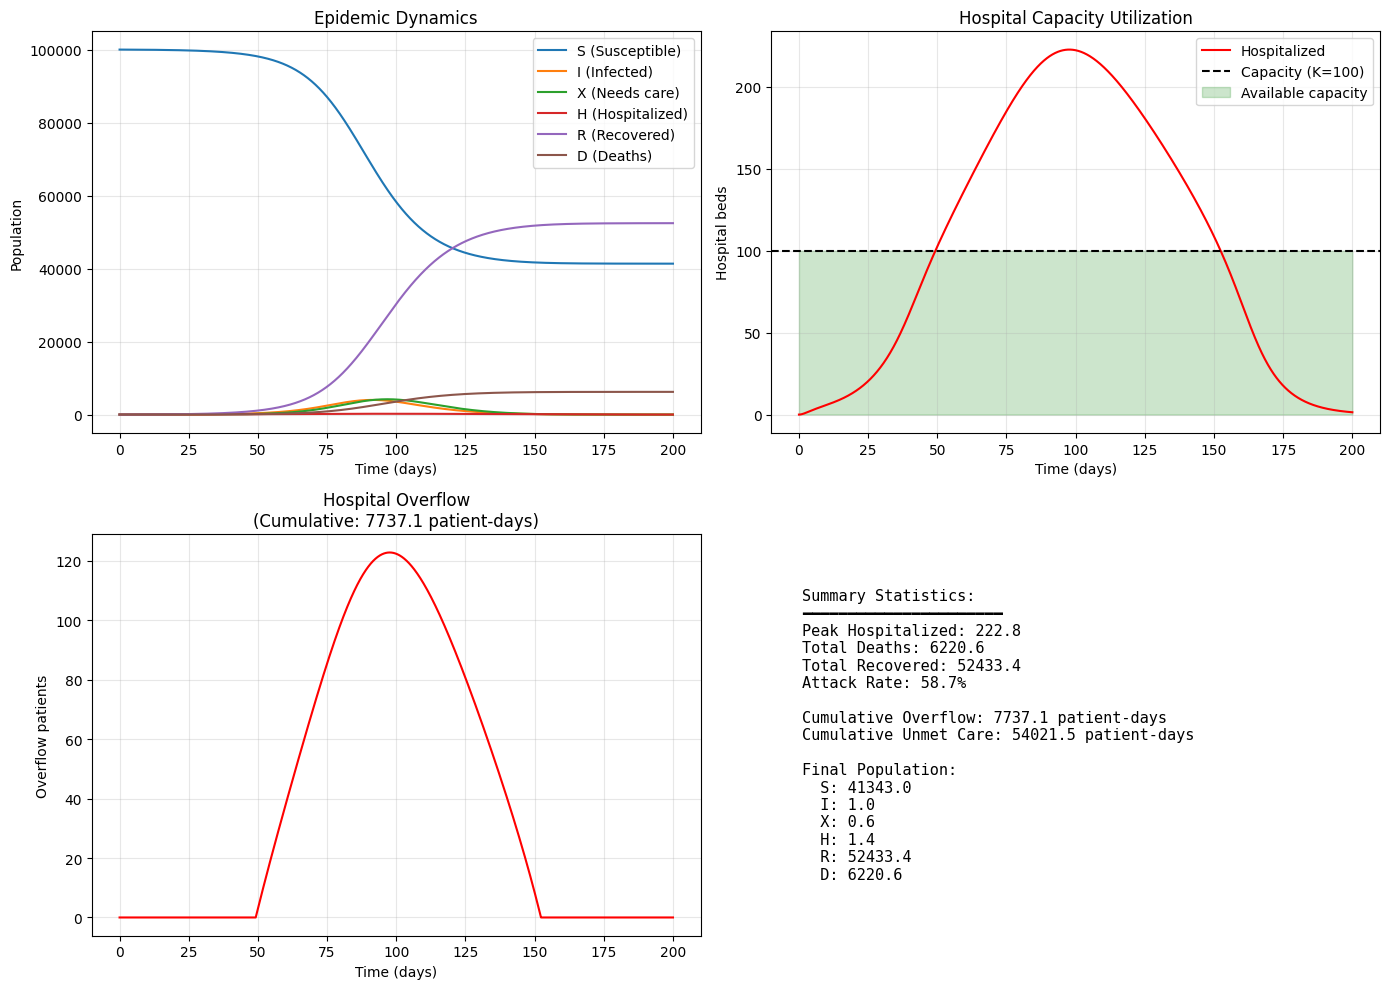


Simulation complete!
Total deaths: 6221
Peak hospital occupancy: 222.8 (Capacity: 100)
Cumulative overflow: 7737.1 patient-days
Cumulative unmet care: 54021.5 patient-days


(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Epidemic Dynamics'}, xlabel='Time (days)', ylabel='Population'>,
         <Axes: title={'center': 'Hospital Capacity Utilization'}, xlabel='Time (days)', ylabel='Hospital beds'>],
        [<Axes: title={'center': 'Hospital Overflow\n(Cumulative: 7737.1 patient-days)'}, xlabel='Time (days)', ylabel='Overflow patients'>,
         <Axes: >]], dtype=object))

In [3]:
single_params = config.MIDDLE_PARAMS
times, S, I, X, H, R, D, overflow, cum_overflow, cum_unmet, unmet = simulate_basic_hospital_model(
    beta=beta,
    sigma=single_params['sigma'],
    eta=single_params['eta'],
    gamma_I=single_params['gamma_I'],
    mu_I=single_params['mu_I'],
    gamma_X=single_params['gamma_X'],
    mu_X=single_params['mu_X'],
    gamma_H=single_params['gamma_H'],
    mu_H=single_params['mu_H'],
    coverage=0.2,
    N=100000,
    hosp_capacity=capacity_params['total_capacity']
)
plot_hospital_simulation_stats(
    times, S, I, X, H, R, D, overflow, cum_overflow, cum_unmet,
    hosp_capacity=capacity_params['total_capacity'], N=100000
)


## Age-structured model
Shared hospital capacity with heterogenous contact patterns and vaccination by age.

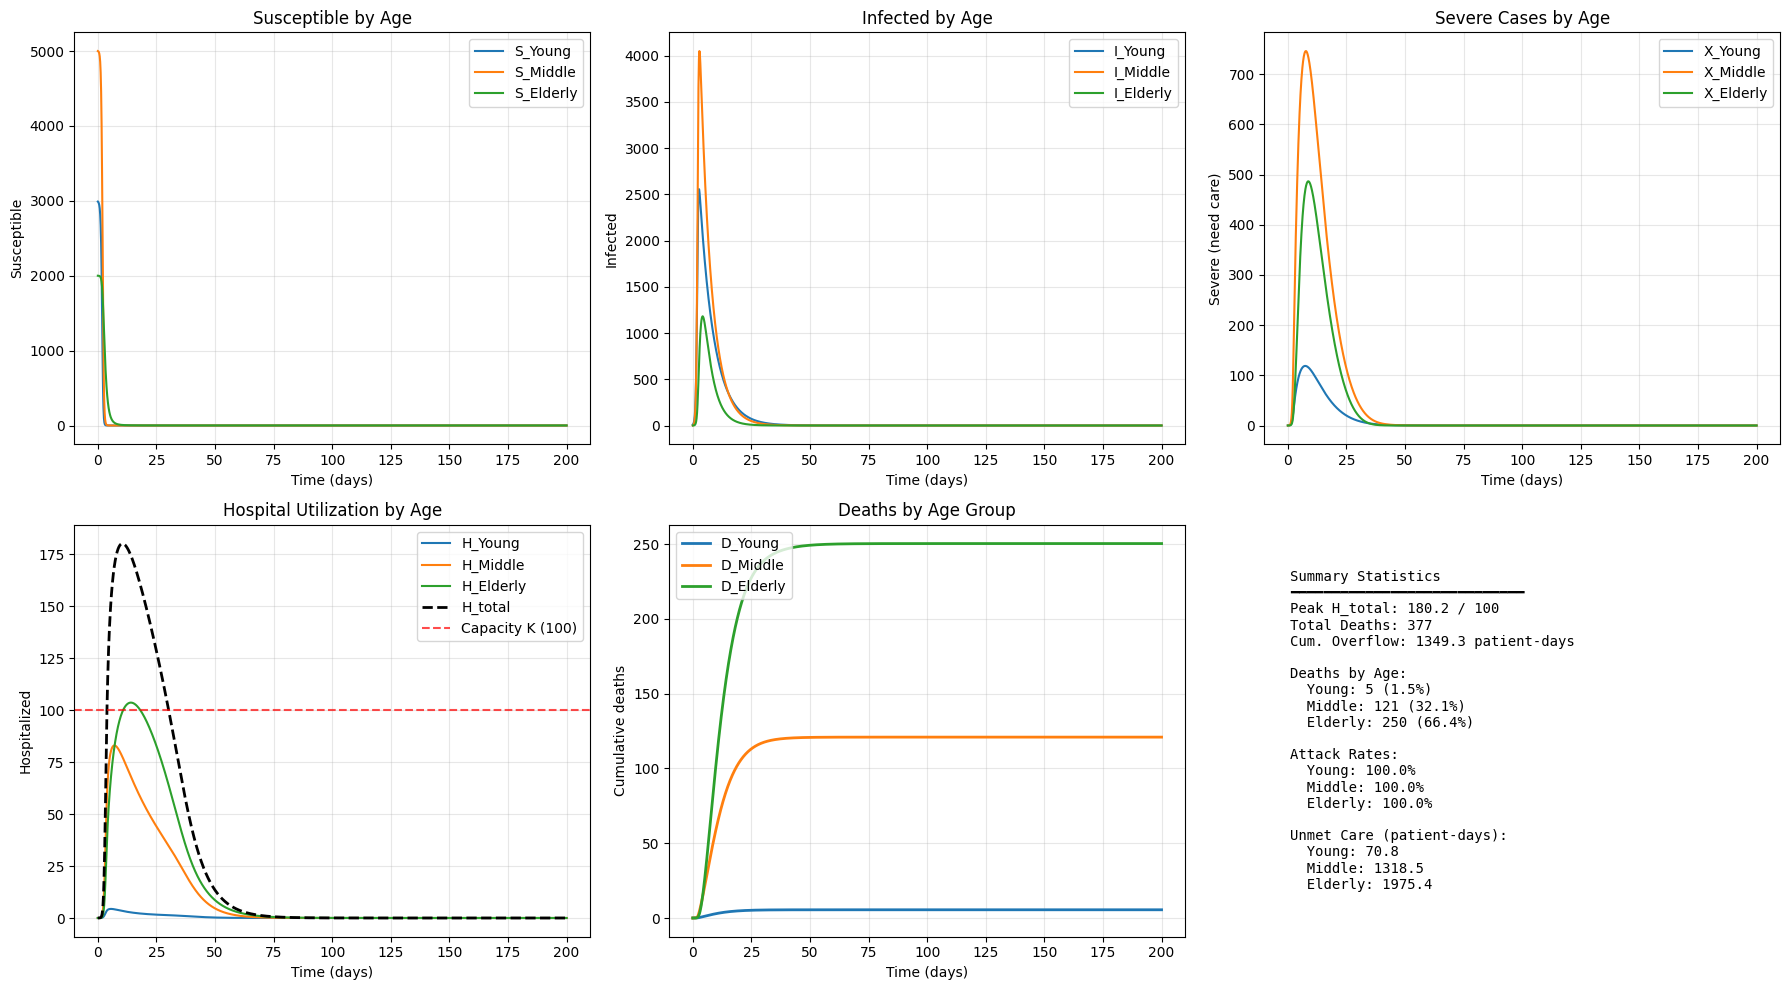


Age-Structured Model Results
Total deaths: 377
Peak hospital occupancy: 180.2 (Capacity: 100)
Cumulative overflow: 1349.3 patient-days
  Young: 5 deaths, AR=100.0%
  Middle: 121 deaths, AR=100.0%
  Elderly: 250 deaths, AR=100.0%


(<Figure size 1800x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Susceptible by Age'}, xlabel='Time (days)', ylabel='Susceptible'>,
         <Axes: title={'center': 'Infected by Age'}, xlabel='Time (days)', ylabel='Infected'>,
         <Axes: title={'center': 'Severe Cases by Age'}, xlabel='Time (days)', ylabel='Severe (need care)'>],
        [<Axes: title={'center': 'Hospital Utilization by Age'}, xlabel='Time (days)', ylabel='Hospitalized'>,
         <Axes: title={'center': 'Deaths by Age Group'}, xlabel='Time (days)', ylabel='Cumulative deaths'>,
         <Axes: >]], dtype=object))

In [4]:
age_results = simulate_age_structured_hospital_model(
    beta=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=capacity_params['total_capacity'],
    hill_coef=sim_params['hill_coef'],
    coverage=elderly_priority_vaccination,
    VE=sim_params['VE'],
    age_pops=age_pops
)
plot_age_structured_results(age_results, hosp_capacity=capacity_params['total_capacity'],
                           age_labels=config.AGE_LABELS_SHORT)


## Ward/ICU separated model
Tracks differential mortality when ward or ICU beds are saturated.

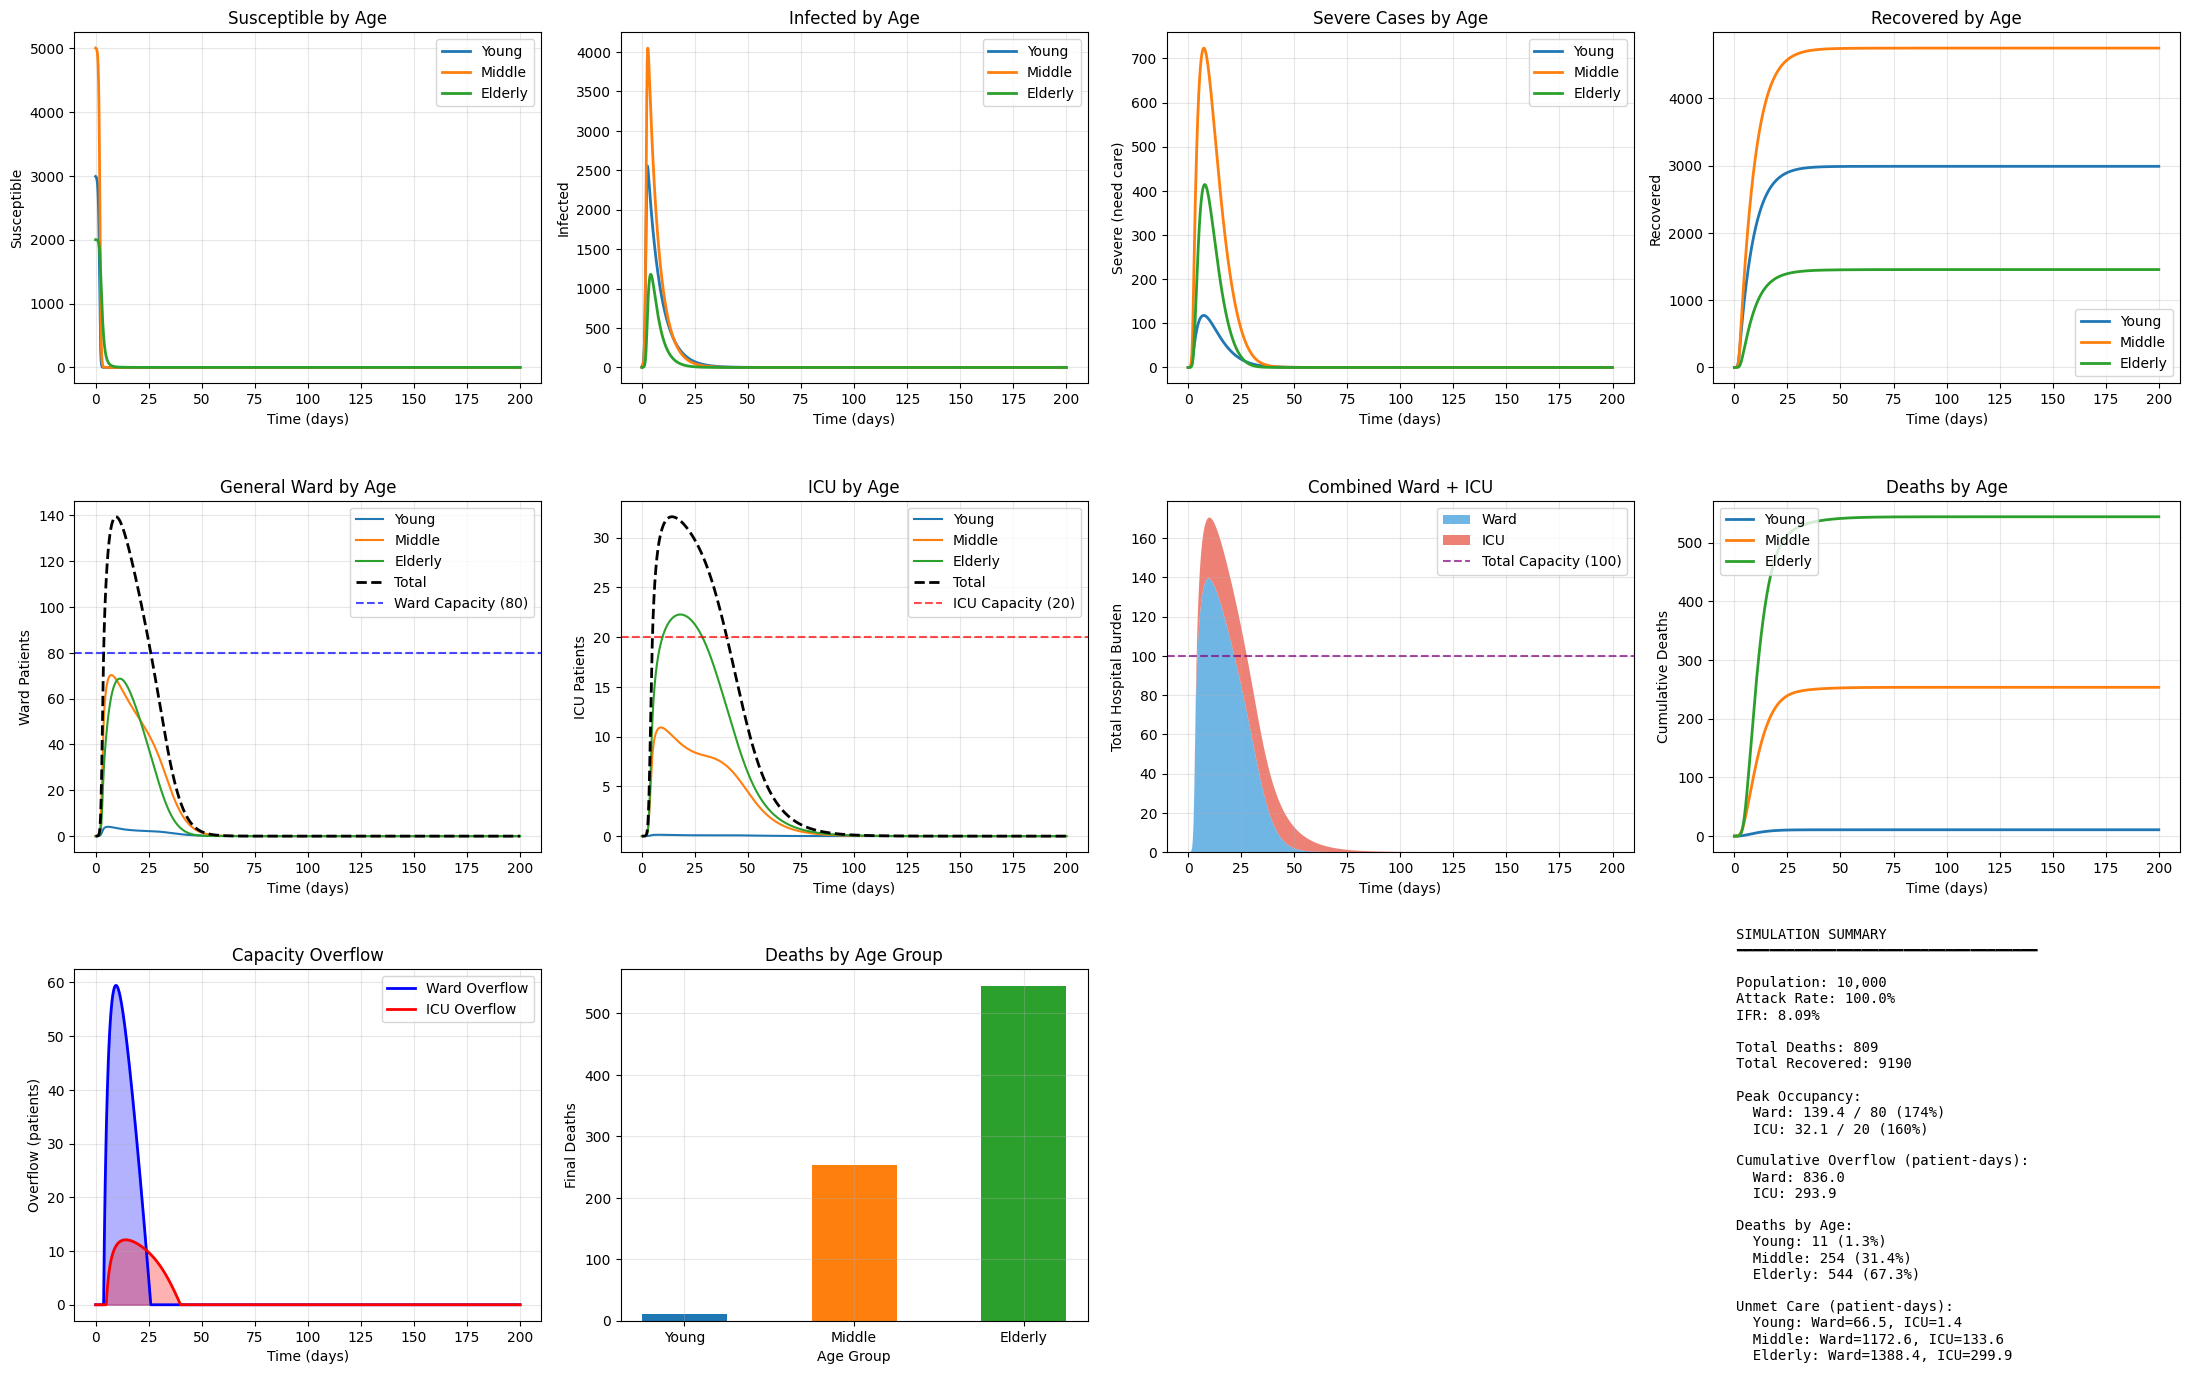


Age-Structured ICU Model Results
Population: 10,000
Attack rate: 100.0%
IFR: 8.09%
Total deaths: 809
Peak ward: 139.4 / 80 (174%)
Peak ICU: 32.1 / 20 (160%)
Cumulative overflow - Ward: 836.0, ICU: 293.9

Deaths by age:
  Young: 11
  Middle: 254
  Elderly: 544


(<Figure size 2200x1400 with 12 Axes>,
 array([[<Axes: title={'center': 'Susceptible by Age'}, xlabel='Time (days)', ylabel='Susceptible'>,
         <Axes: title={'center': 'Infected by Age'}, xlabel='Time (days)', ylabel='Infected'>,
         <Axes: title={'center': 'Severe Cases by Age'}, xlabel='Time (days)', ylabel='Severe (need care)'>,
         <Axes: title={'center': 'Recovered by Age'}, xlabel='Time (days)', ylabel='Recovered'>],
        [<Axes: title={'center': 'General Ward by Age'}, xlabel='Time (days)', ylabel='Ward Patients'>,
         <Axes: title={'center': 'ICU by Age'}, xlabel='Time (days)', ylabel='ICU Patients'>,
         <Axes: title={'center': 'Combined Ward + ICU'}, xlabel='Time (days)', ylabel='Total Hospital Burden'>,
         <Axes: title={'center': 'Deaths by Age'}, xlabel='Time (days)', ylabel='Cumulative Deaths'>],
        [<Axes: title={'center': 'Capacity Overflow'}, xlabel='Time (days)', ylabel='Overflow (patients)'>,
         <Axes: title={'center': 'Dea

In [5]:
icu_results = simulate_age_structured_hospital_model_with_icu_ward_split(
    beta=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    ward_capacity=capacity_params['ward_capacity'],
    icu_capacity=capacity_params['icu_capacity'],
    hill_coef_ward=capacity_params['hill_coef_ward'],
    hill_coef_icu=capacity_params['hill_coef_icu'],
    coverage=elderly_priority_vaccination,
    VE=sim_params['VE'],
    age_pops=age_pops
)
plot_age_structured_icu_results(icu_results, age_labels=config.AGE_LABELS_SHORT, 
                                 show_all_compartments=True)


## Time-varying transmission (seasonality + policy + waning)
Demonstrates seasonality, lockdown, and waning immunity effects.

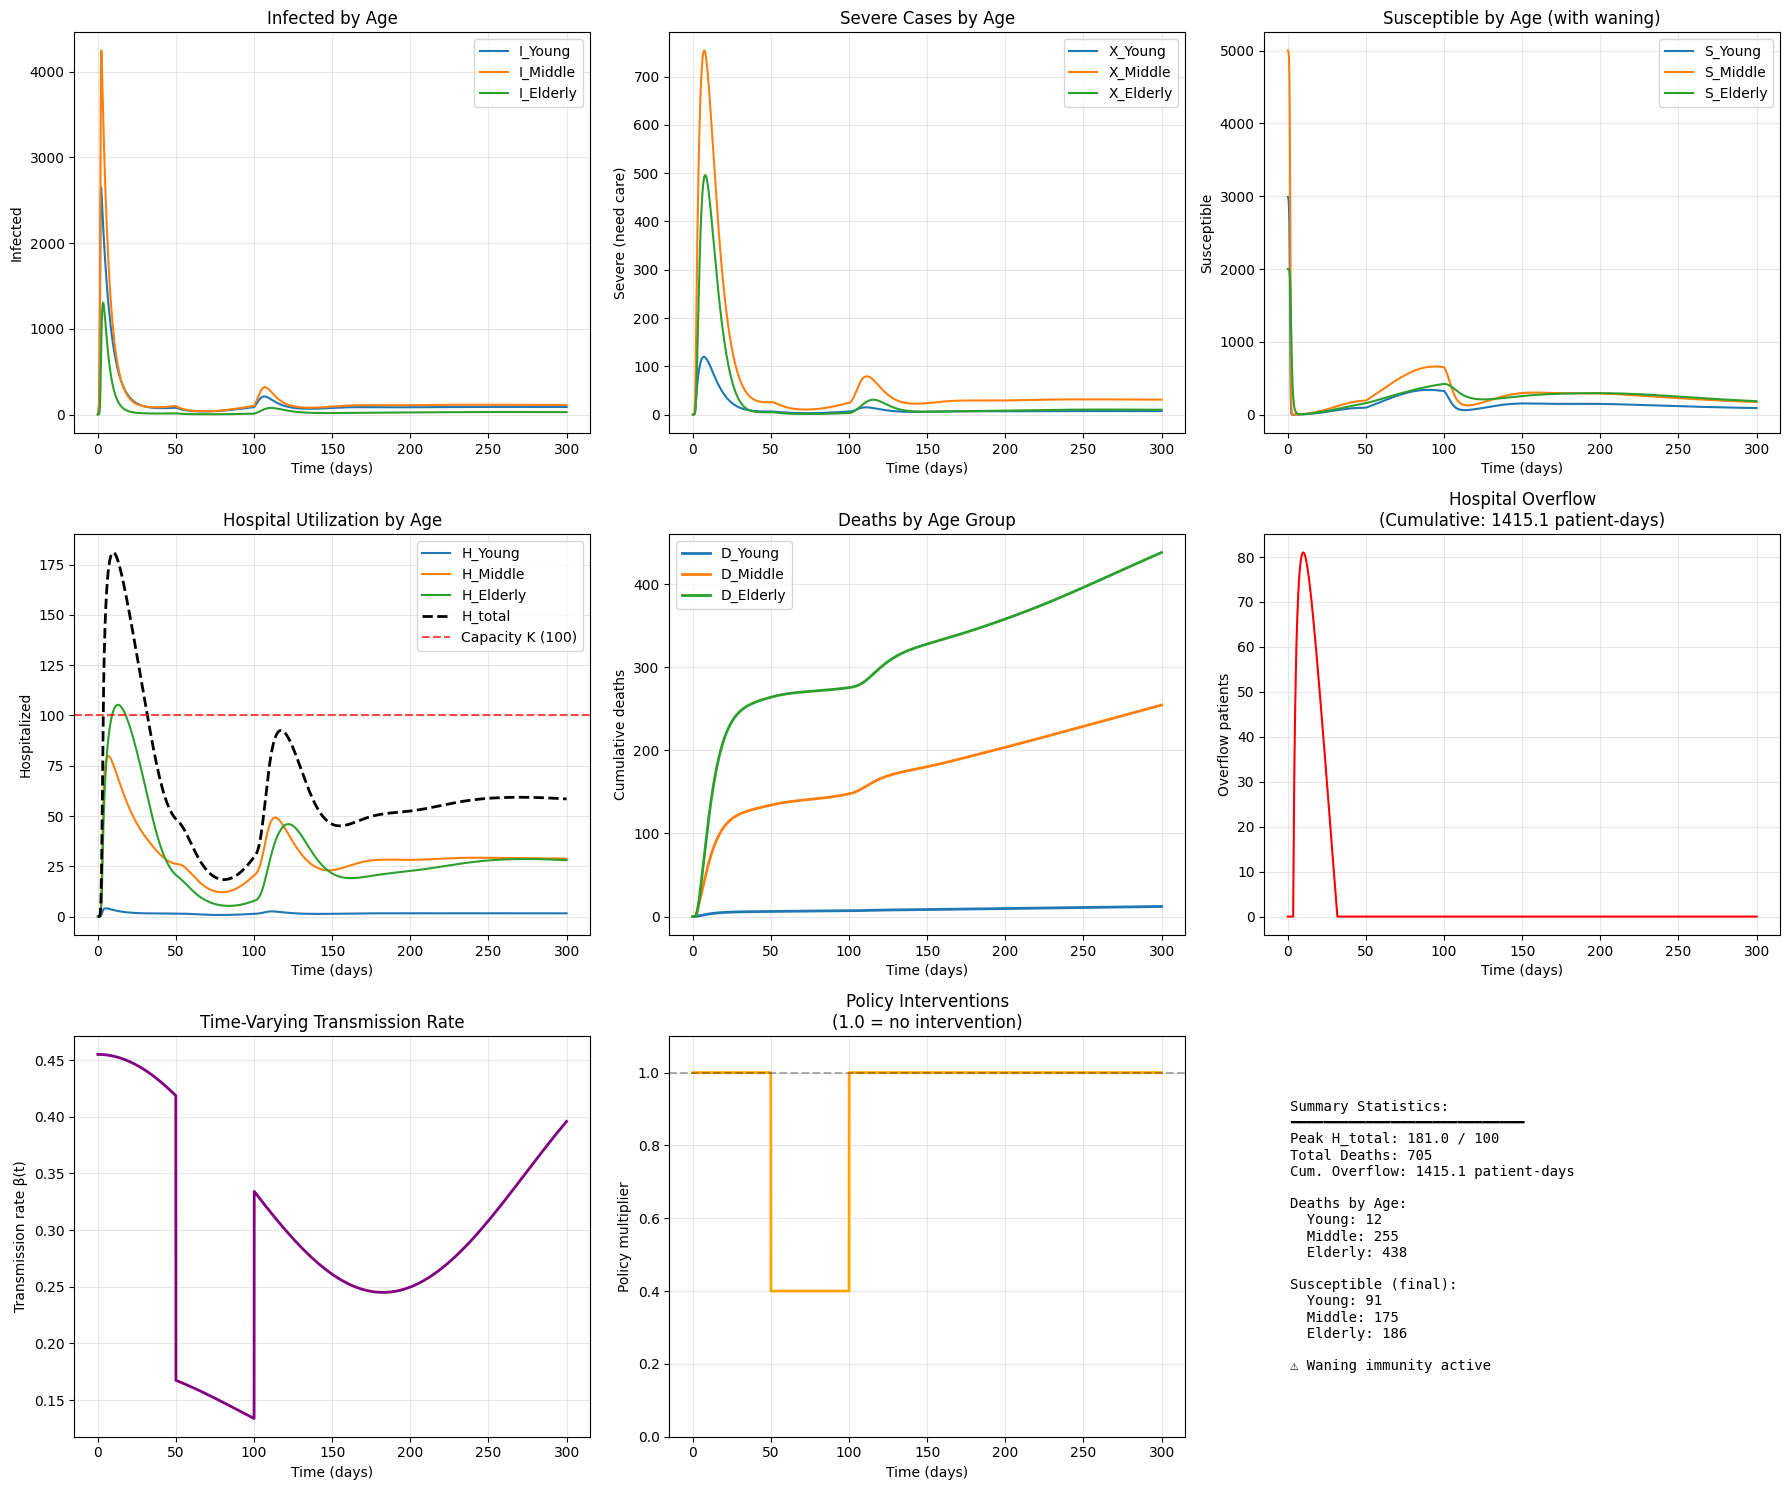


Time-Varying Model Results
Total deaths: 705
Peak hospital occupancy: 181.0 (Capacity: 100)
Cumulative overflow: 1415.1 patient-days
Beta range: [0.134, 0.455]


(<Figure size 1800x1500 with 9 Axes>,
 array([[<Axes: title={'center': 'Infected by Age'}, xlabel='Time (days)', ylabel='Infected'>,
         <Axes: title={'center': 'Severe Cases by Age'}, xlabel='Time (days)', ylabel='Severe (need care)'>,
         <Axes: title={'center': 'Susceptible by Age (with waning)'}, xlabel='Time (days)', ylabel='Susceptible'>],
        [<Axes: title={'center': 'Hospital Utilization by Age'}, xlabel='Time (days)', ylabel='Hospitalized'>,
         <Axes: title={'center': 'Deaths by Age Group'}, xlabel='Time (days)', ylabel='Cumulative deaths'>,
         <Axes: title={'center': 'Hospital Overflow\n(Cumulative: 1415.1 patient-days)'}, xlabel='Time (days)', ylabel='Overflow patients'>],
        [<Axes: title={'center': 'Time-Varying Transmission Rate'}, xlabel='Time (days)', ylabel='Transmission rate β(t)'>,
         <Axes: title={'center': 'Policy Interventions\n(1.0 = no intervention)'}, xlabel='Time (days)', ylabel='Policy multiplier'>,
         <Axes: >]], dt

In [6]:
timevarying_results = simulate_age_structured_hospital_model_with_time_variance(
    beta_base=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=capacity_params['total_capacity'],
    hill_coef=sim_params['hill_coef'],
    coverage=elderly_priority_vaccination,
    VE=sim_params['VE'],
    age_pops=age_pops,
    seasonal_params=config.SEASONAL_PARAMS,
    waning_params={'omega': config.WANING_PARAMS['omega']},
    interventions=config.LOCKDOWN_SCENARIO,
    Tmax=300
)
plot_time_varying_results(timevarying_results, hosp_capacity=capacity_params['total_capacity'],
                           age_labels=config.AGE_LABELS_SHORT)


## Vaccination strategy comparison
Runs all configured strategies and lists the lowest-death options.

In [7]:
# Compare strategies and use helper to format results
strategy_summary = compare_vaccination_strategies(
    beta=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=capacity_params['total_capacity'],
    age_pops=age_pops,
    strategies=config.VACCINATION_STRATEGIES,
    hill_coef=sim_params['hill_coef'],
    VE=sim_params['VE'],
    verbose=False
)

# Use new helper to display results table
print_comparison_table(
    strategy_summary,
    title="Top Vaccination Strategies by Deaths",
    sort_by='total_deaths',
    top_n=3
)


Top Vaccination Strategies by Deaths
  Middle priority: deaths=376, peak_H=181.1, overflow=1347.3
  Young priority: deaths=377, peak_H=181.2, overflow=1347.0
  No vaccination: deaths=377, peak_H=181.3, overflow=1346.7


## Vaccine allocation grid search (fixed total coverage)
Grid search over young/middle coverage with implied elderly coverage to minimize deaths.

Searching for optimal allocation of 3000 vaccine doses...
(Equivalent to 30% of total population)
Search complete.
Optimal coverage: young=0.33, middle=0.00, elderly=1.00
Minimum deaths: 374
Overflow at optimum: 1354.5 patient-days


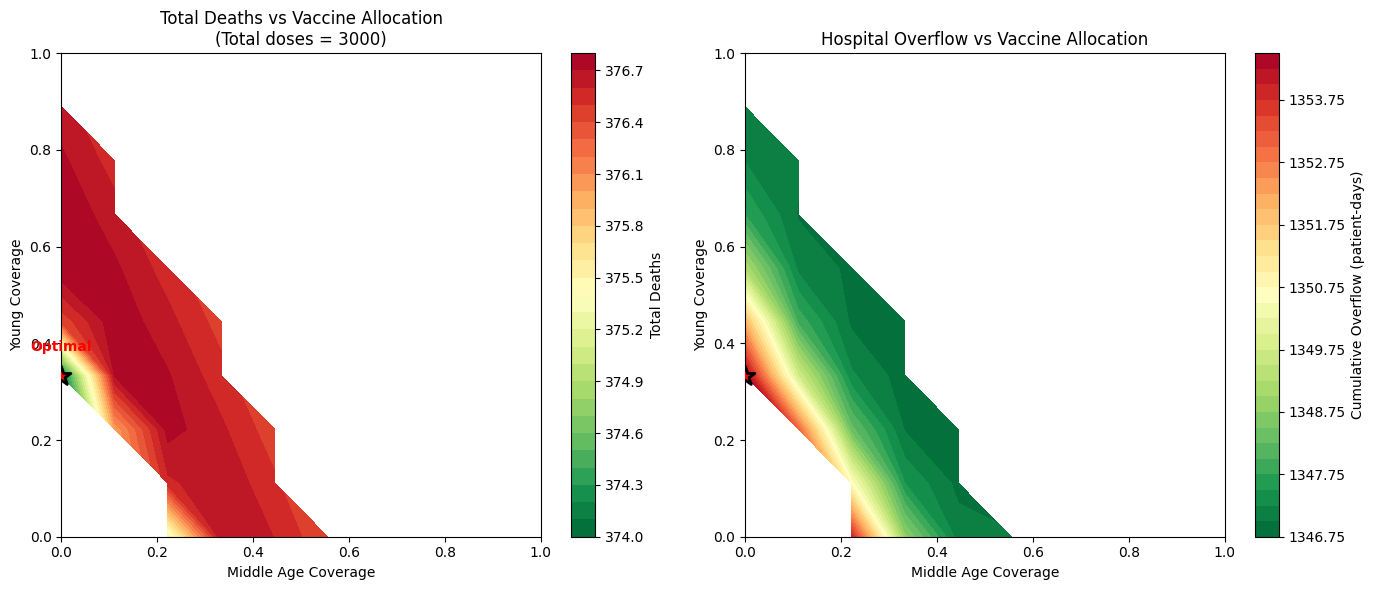


OPTIMAL ALLOCATION (Fixed total: 3000 doses)
Young coverage: 33.3%
Middle coverage: 0.0%
Elderly coverage: 100.0%

Minimum deaths: 374
Overflow at optimum: 1354.5 patient-days


(np.float64(0.3333333333333333),
 np.float64(0.0),
 np.float64(1.0),
 <Figure size 1400x600 with 4 Axes>,
 array([<Axes: title={'center': 'Total Deaths vs Vaccine Allocation\n(Total doses = 3000)'}, xlabel='Middle Age Coverage', ylabel='Young Coverage'>,
        <Axes: title={'center': 'Hospital Overflow vs Vaccine Allocation'}, xlabel='Middle Age Coverage', ylabel='Young Coverage'>],
       dtype=object))

In [8]:
from plotting_utils import plot_optimal_allocation
# Grid search for optimal vaccine allocation
total_coverage_target = 0.3  # 30% of total population
deaths_grid, overflow_grid, young_range, middle_range = optimize_vaccine_allocation(
    beta=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=capacity_params['total_capacity'],
    age_pops=age_pops,
    total_coverage_target=total_coverage_target,
    n_grid=10,
    hill_coef=sim_params['hill_coef'],
    VE=sim_params['VE'],
    theta_X=sim_params['theta_X'],
    theta_H=sim_params['theta_H']
)

# Extract optimal allocation using helper pattern
opt_idx = np.nanargmin(deaths_grid)
iy, im = np.unravel_index(opt_idx, deaths_grid.shape)
total_doses = total_coverage_target * sum(age_pops)

# Use structured output
optimal_allocation = {
    'young': young_range[iy],
    'middle': middle_range[im],
    'elderly': (total_doses - young_range[iy] * age_pops[0] - middle_range[im] * age_pops[1]) / age_pops[2],
    'min_deaths': np.nanmin(deaths_grid),
    'overflow': overflow_grid[iy, im]
}

print(f"Optimal coverage: young={optimal_allocation['young']:.2f}, "
      f"middle={optimal_allocation['middle']:.2f}, elderly={optimal_allocation['elderly']:.2f}")
print(f"Minimum deaths: {optimal_allocation['min_deaths']:.0f}")
print(f"Overflow at optimum: {optimal_allocation['overflow']:.1f} patient-days")

plot_optimal_allocation(
    age_pops=age_pops,
    total_doses=total_coverage_target * sum(age_pops),
    deaths_grid=deaths_grid,
    overflow_grid=overflow_grid,
    young_range=young_range,
    middle_range=middle_range
    )

## Capacity sweep
Explore ward/ICU splits for a fixed total bed count.

In [9]:
# Sweep ICU capacity allocation
optimal_capacity = sweep_icu_capacity(
    beta=beta,
    age_params=age_params,
    contact_matrix=contact_matrix,
    age_pops=age_pops,
    total_beds=capacity_params['total_capacity'],
    coverage=elderly_priority_vaccination,
    n_points=12,
    verbose=False
)

# Access results using consistent dictionary keys
print(f"Optimal ICU fraction (sweep): {optimal_capacity['optimal_icu_fraction']:.1%}")
print(f"Minimum deaths (sweep): {optimal_capacity['optimal_deaths']:.0f}")

Optimal ICU fraction (sweep): 5.0%
Minimum deaths (sweep): 797
